In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

In [3]:
dfield_path = "/p/data1/pli/Private/oberstrass1/bigbrains/S01/dfield/0070_polyaffine_transform_deformation.h5"
section_path = "/p/data1/pli/Private/oberstrass1/bigbrains/S01/scans/S01_0070_Slice15.tif"
gt_path = "/p/data1/pli/Private/oberstrass1/bigbrains/S01/dfield/S01_0070_Slice15_transformed.tif"

request_margin = 0

###

from tiamat.transformers.dfield import DeformationFieldTransformer
from tiamat.readers import BigTiffReader

section_reader = BigTiffReader(section_path)
gt_reader = BigTiffReader(gt_path)
gt_reader.scales = [4.]

dfield_transformer = DeformationFieldTransformer(dfield_path, request_margin=0)

section_reader.shape, gt_reader.shape

((14059, 19450), (3750, 3750))

In [4]:
x = (0, 512)
y = (2048, 2560)

###

from tiamat.io import ImageAccessor

test_access = ImageAccessor(
    x=x,
    y=y,
    fill_value=255,
    coordinate_spacing=1.0,
    coordinate_scale=1.0,
)

###

image_accessor = dfield_transformer.transform_access(test_access)

image_accessor.x, image_accessor.y

((227, 810), (-37, 556))

(593, 583)

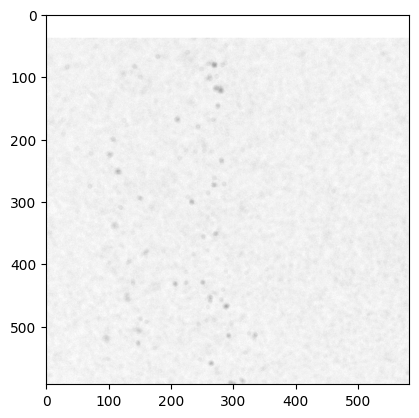

In [5]:
image_accessor.metadata = section_reader.read_metadata()
image_result = section_reader.read_image(image_accessor)

plt.imshow(image_result.image, cmap='gray', vmin=0, vmax=255)
image_result.image.shape

(512, 512)

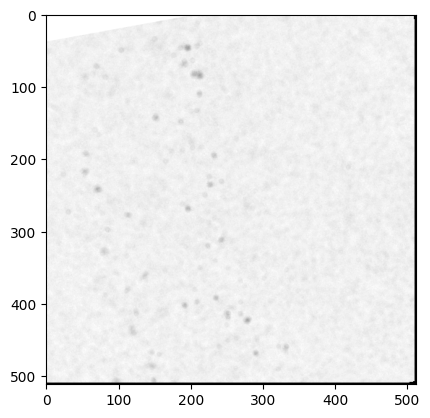

In [6]:
out_result = dfield_transformer.transform_image(image_result)

plt.imshow(out_result.image, cmap='gray', vmin=0, vmax=255)
out_result.image.shape

(3750, 3750)

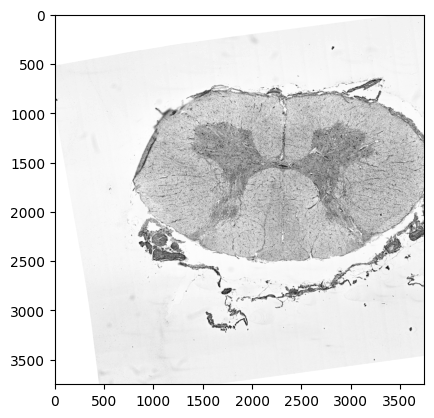

In [7]:
from tiamat import metadata as md

gt_image = gt_reader.file_handle[:]

plt.imshow(gt_image, cmap='gray', vmin=0, vmax=255)
gt_image.shape